In [104]:
%reload_ext autoreload
%autoreload 2

In [105]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_uv_coverage


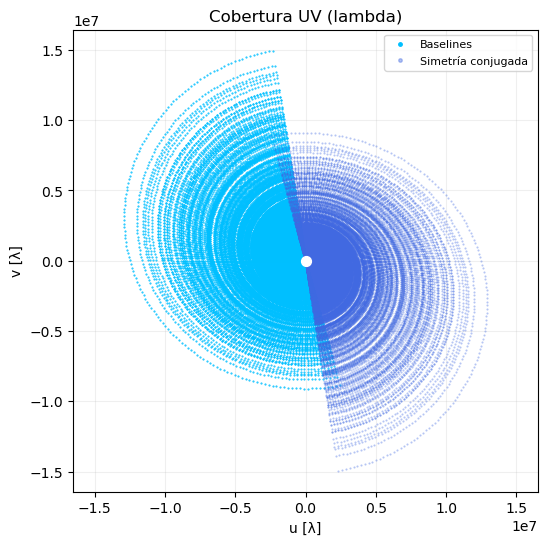

In [106]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-10-10T00:00:00",
  "utc_end": "2025-10-10T12:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 10,
  "max_offset_deg": 0.12,
  "flux_range": [5.0, 5.0],
  "seed":42
  }

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, sources , [l,m,n] , times_sec = visibilities_simulation(VLA_L_4)

# plot_uv_coverage_2(uvw, 512, title="test")
plot_uv_coverage(uvw, unit='lambda')

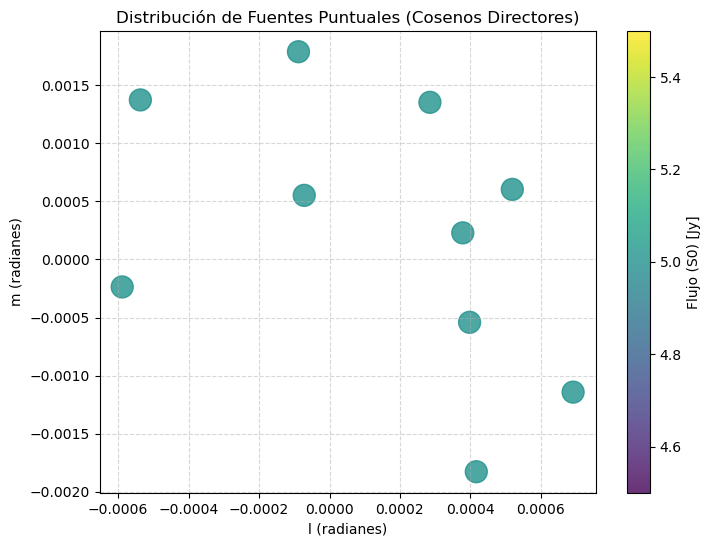

In [107]:
from modules.plots import plot_sources

plot_sources(l, m, sources)

In [126]:
# Gridding
from modules.gridder import grid_visibilities, get_grid_config

N = 512

grid_config = get_grid_config(V, uvw_lambda, N, baselines_enu, oversampling_factor=0.7, frequencies=frequencies)
grid_config.keys()

dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

In [127]:
VG, WG = grid_visibilities(grid_config=grid_config, mode="cupy")

Backend a utilizar: cupy


Generating plot with scale: 8 (Figure size: 16.0x8.0 inches)


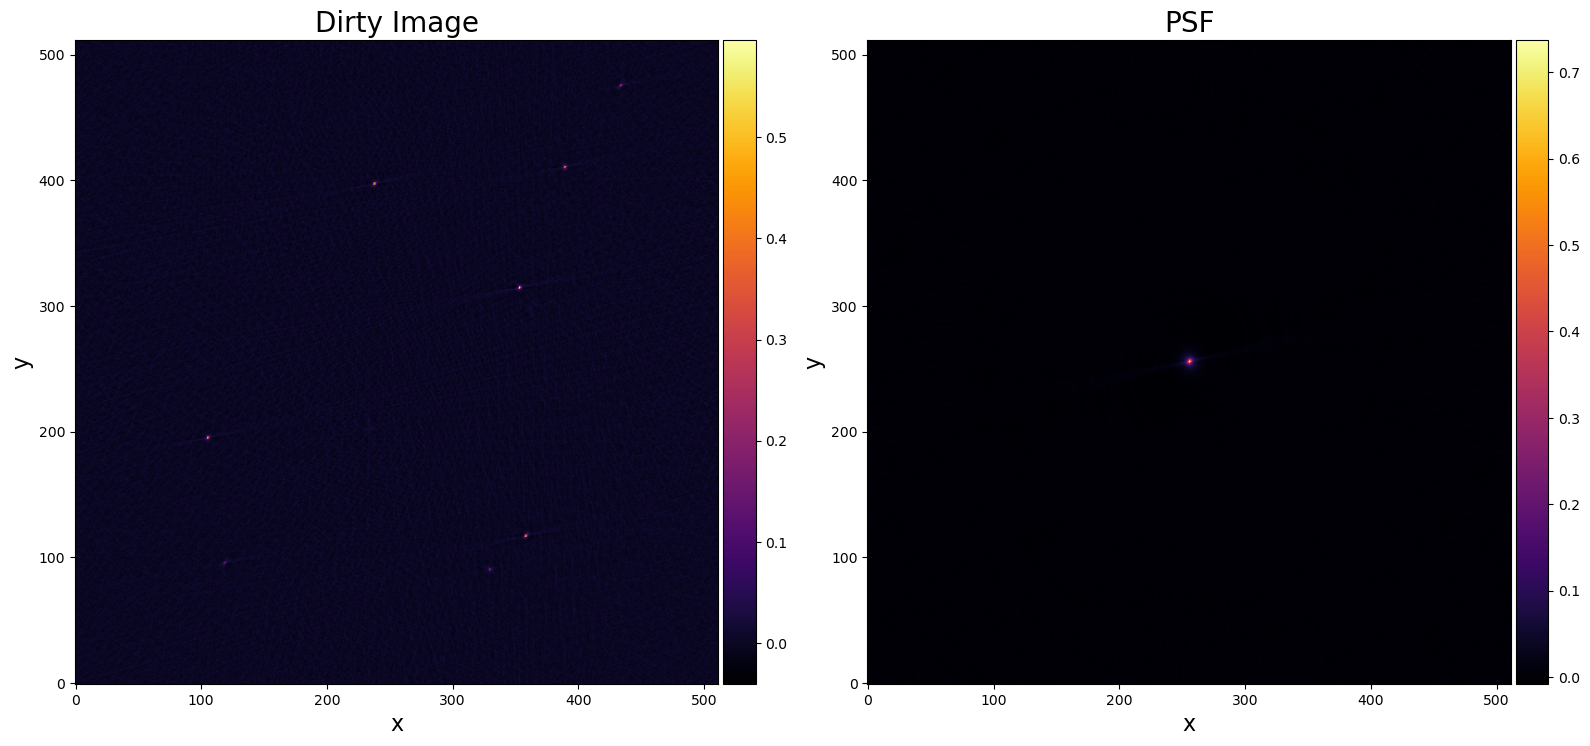

In [128]:
from modules.interferometry import get_dirty_image, get_psf, get_clean_beam
from modules.plots import plot
import cupy as cp

dirty_image = get_dirty_image(VG)
psf = get_psf(WG)


images = [
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':psf, 'title':'PSF', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(images, (1,2), scale=8)

In [138]:
from modules.clean import clean
from modules.backend import fftconvolve
import numpy as np

clean_beam = get_clean_beam(N, pixel_size=grid_config["pixel_size_image"], uvw_lambda=cp.asarray(uvw_lambda))
model_img, residuals = clean(dirty_image, max_iter=2000, threshold=0.01, gain=0.1)

clean_img = fftconvolve(model_img, clean_beam, mode="same") + residuals

test = np.abs(clean_img - dirty_image)


Generating plot with scale: 8 (Figure size: 16.0x16.0 inches)


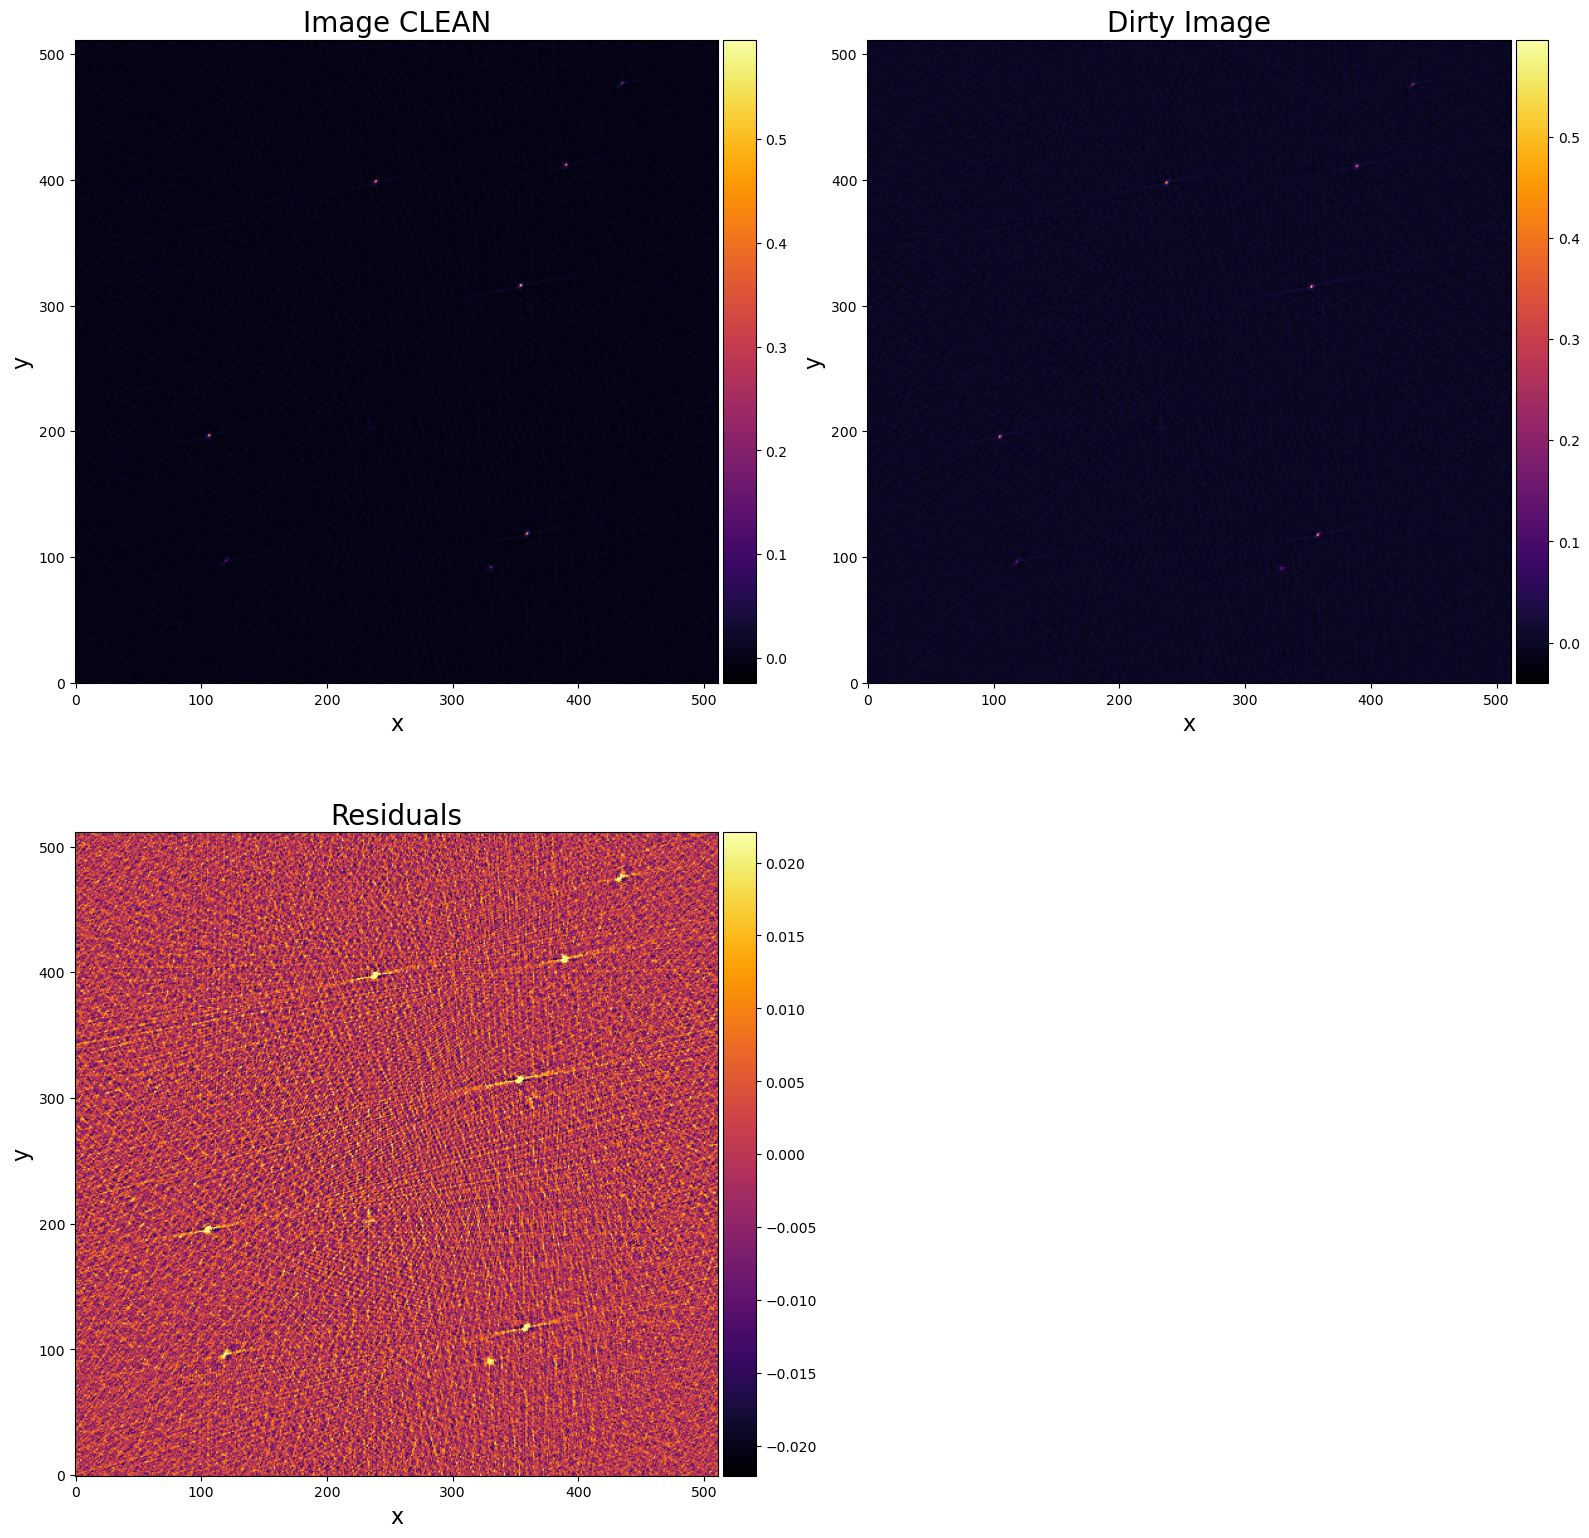

In [139]:
plot([{'image':clean_img.get(), 'title':'Image CLEAN', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
      {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
      {'image':residuals, 'title':'Residuals', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    ],
    (2,2), scale=8)